# IEEE 8500-node feeder — OpenDSS timing (GNN2)

**This notebook file:** `IEEE8500_OpenDSS_timing.ipynb` (in your `GNN2` project folder)

**Not** the `8500-node` **folder** — that folder only holds OpenDSS `.dss` data files.

**Goal:** find `Master.dss`, run snapshot power flow, and measure **median `Solve()` time (ms)** to compare later with GNN inference at batch size 1.

| Step | What |
|------|------|
| **1** | Point OpenDSS at `Master.dss` |
| **2** | Load circuit + time 50 snapshot solves |
| **3** | Generate load-type CSVs (`run_loadtype_dataset_8500`) |
| **4** | Build `edge_index` / `edge_attr` (`build_graph_8500`) |
| **5** | Stack node `X` / `Y` tensors (`assemble_dataset_tensors_8500`) |
| **6** | MLP sweep: 5 architectures, best saved (`train_mlp_8500`) |

Run cells **in order** (top to bottom).


## Step 1 — Path to `Master.dss`

The feeder is a **folder of `.dss` files**. The **entry file** is **`Master.dss`**. Your copy lives in **`GNN2/8500-node`**.

**This step:** set `LOCAL_8500_DIR` if you move the folder, run the code cell, and confirm it prints **`Master.dss`**.

**Pass:** `Master.dss` exists at the printed path.


In [1]:
import pathlib
import opendssdirect

# --- edit only if you move the feeder folder ---
LOCAL_8500_DIR = pathlib.Path(r"C:\Users\alita\OneDrive\Desktop\GNN2\8500-node")
LOCAL_8500_MASTER = LOCAL_8500_DIR / "Master.dss"

DSS_8500: pathlib.Path | None = None

if LOCAL_8500_MASTER.is_file():
    DSS_8500 = LOCAL_8500_MASTER
else:
    for base in (
        pathlib.Path(opendssdirect.__file__).parent,
        pathlib.Path(r"C:\Program Files\OpenDSS"),
        pathlib.Path(r"C:\OpenDSS"),
    ):
        if not base.exists():
            continue
        try:
            for f in base.rglob("Master.dss"):
                if "8500" in str(f).lower():
                    DSS_8500 = f
                    break
        except (OSError, PermissionError):
            pass
        if DSS_8500 is not None:
            break

if DSS_8500 is None:
    print("Master.dss not found. Place the full 8500-node folder at:")
    print(" ", LOCAL_8500_DIR)
else:
    print("Using entry file:", DSS_8500.resolve())


Using entry file: C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\Master.dss


**Checkpoint — Step 1 done**

You have the OpenDSS entry file **`Master.dss`**.

**Next:** Step 2 loads the circuit and measures solve time.


## Step 2 — Load circuit and profile `Solve()`

**This step:** `Redirect` `Master.dss`, run one solve (convergence + bus counts), then **50** snapshot solves and report **median / mean / min / max** in **ms**.

**Note:** `from opendssdirect import dss` is required — the **package** is not callable (`import opendssdirect as dss` breaks `dss(...)`).

**Pass:** `Converged: True`, buses ~4876, node-phases ~8500+, and a stable median time.


In [2]:
# Step 2 — load + time snapshot solves
import statistics
import time

import pathlib

from opendssdirect import dss

LOCAL_8500_MASTER = pathlib.Path(r"C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\Master.dss")
_d = globals().get("DSS_8500")
if _d is not None:
    DSS_8500 = _d
elif LOCAL_8500_MASTER.is_file():
    DSS_8500 = LOCAL_8500_MASTER
else:
    DSS_8500 = None
if DSS_8500 is None:
    raise RuntimeError("Run Step 1 or place Master.dss at GNN2/8500-node/Master.dss")

dss(f'redirect "{DSS_8500.resolve()}"')
dss.Solution.Mode(1)
dss.Solution.Solve()

converged = dss.Solution.Converged()
n_buses = len(dss.Circuit.AllBusNames())
all_nodes = dss.Circuit.AllNodeNames()
n_nodes = len([n for n in all_nodes if "." in n and n.split(".")[1] in ("1", "2", "3")])

print("Circuit:", DSS_8500)
print(f"  Converged    : {converged}")
print(f"  Buses        : {n_buses}")
print(f"  Node-phases  : {n_nodes} (phases 1/2/3)")
print(f"  Control iter : {dss.Solution.ControlIterations()}")
print(f"  PF iter      : {dss.Solution.Iterations()}")

times_ms = []
for _ in range(50):
    t0 = time.perf_counter()
    dss.Solution.Solve()
    times_ms.append((time.perf_counter() - t0) * 1000.0)

med = statistics.median(times_ms)
print()
print("Solve() time over 50 runs (ms):")
print(f"  median : {med:.3f} ms")
print(f"  mean   : {statistics.mean(times_ms):.3f} ms")
print(f"  min    : {min(times_ms):.3f} ms")
print(f"  max    : {max(times_ms):.3f} ms")
print()
print(f"→ Rough batch-1 target vs pure Solve(): beat ~{med:.1f} ms/step")


Circuit: C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\Master.dss
  Converged    : True
  Buses        : 4876
  Node-phases  : 8541 (phases 1/2/3)
  Control iter : 1
  PF iter      : 2

Solve() time over 50 runs (ms):
  median : 47.016 ms
  mean   : 49.884 ms
  min    : 42.119 ms
  max    : 80.902 ms

→ Rough batch-1 target vs pure Solve(): beat ~47.0 ms/step


**Checkpoint — Step 2 done**

You now have **median `Solve()` time** for this machine on the 8500-node case. Use it as an order-of-magnitude bar when comparing to a surrogate (plus PyTorch overhead, etc.).

---

## Step 3 — Generate load-type dataset (8500)

Run the **next code cell** to execute `run_loadtype_dataset_8500.py`. It writes the same style of CSVs as `run_loadtype_dataset.py`, but for **`8500-node/Master.dss`**, under **`datasets_gnn2/loadtype_8500/`**.

Edit **`n_samples`** (and seeds) in that cell if you want a smaller test first.

---

## Step 4 — Build static graph tensors (`edge_index`, `edge_attr`)

Run **after Step 3** so `gnn_edges_phase_static.csv` and `gnn_node_index_master.csv` exist. The script **`build_graph_8500.py`** writes **`graph_tensors/edge_index.pt`**, **`edge_attr.pt`**, **`graph_meta.json`**, and **`node_index_map.json`** under **`datasets_gnn2/loadtype_8500/`**.

---

## Step 5 — Stack node features / targets (`X`, `Y`)

Run **after Steps 3–4** so `gnn_node_features_and_targets.csv` exists and **`graph_meta.json`** can validate **N**. **`assemble_dataset_tensors_8500.py`** writes **`dataset_tensors/X.pt`**, **`Y.pt`**, optional **`Y_angle.pt`** (`vang_deg`), and **`tensor_manifest.json`**.

---

## Step 6 — MLP baseline (checklist *Step 5*)

Run **after Step 5** so **`X.pt`** / **`Y.pt`** exist. **`train_mlp_8500.py`** trains **five** MLP shapes on **MSE(|V|) only** (no angle), saves each under **`mlp_sweep_8500/<name>/`**, writes **`sweep_summary.json`**, and copies the **best** test MAE to **`mlp_sweep_8500/best/`**. For a **single** run use `train_mlp_baseline_8500()`. The checklist target is **test MAE under 0.005 pu** on \|V\| — expect to **increase `n_samples`** (e.g. 5k–10k) in Step 3 first.

---

## Later (outside this notebook)

- Train **`train_gnn_8500`** (checklist Step 6), then benchmark inference vs OpenDSS.


In [ ]:
# Step 3 — same pattern as GNN2 notebook: chdir to repo, run dataset script
import os

try:
    import run_loadtype_dataset_8500 as _lt8500

    os.chdir(os.path.dirname(os.path.abspath(_lt8500.__file__)))
except Exception:
    pass

# Same as: exec(open("run_loadtype_dataset_8500.py", encoding="utf-8").read())
from run_loadtype_dataset_8500 import generate_gnn_snapshot_dataset_loadtype_8500

generate_gnn_snapshot_dataset_loadtype_8500(
    n_samples=500,
    master_seed=20260322,
    sigma_load=0.12,
    sigma_pv=0.12,
)

## Step 4 — Static graph from dataset CSVs

**Pass:** `build_graph_8500.build_static_graph_8500()` prints shapes and writes files under `datasets_gnn2/loadtype_8500/graph_tensors/`.

**Next:** Step 5 — stack **`X`** / **`Y`** tensors from `gnn_node_features_and_targets.csv`.

In [ ]:
# Step 4 — edge_index / edge_attr .pt files (requires Step 3 CSVs)
import os

try:
    import build_graph_8500 as _bg
    os.chdir(os.path.dirname(os.path.abspath(_bg.__file__)))
except Exception:
    pass

from build_graph_8500 import build_static_graph_8500

build_static_graph_8500()

## Step 5 — Stacked tensors for training

**Pass:** `assemble_dataset_tensors_8500.assemble_dataset_tensors_8500()` prints shapes and writes **`dataset_tensors/X.pt`**, **`Y.pt`**, **`tensor_manifest.json`**.

Uses the same **14** load-type input columns as `run_gnn3_best7_train.LOADTYPE_FEAT`; target defaults to **`vmag_pu`**, with **`Y_angle.pt`** from **`vang_deg`** when present.

**Next:** Step 6 — five-MLP sweep (`train_mlp_architecture_sweep_8500`).

In [5]:
# Step 5 — X [S,N,F], Y [S,N] aligned with graph node order (needs Steps 3–4)
import os

try:
    import assemble_dataset_tensors_8500 as _ad
    os.chdir(os.path.dirname(os.path.abspath(_ad.__file__)))
except Exception:
    pass

from assemble_dataset_tensors_8500 import assemble_dataset_tensors_8500

assemble_dataset_tensors_8500()

[assemble_dataset_tensors_8500] Saved to C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500\dataset_tensors/
  X (500, 8541, 14)  Y (500, 8541)  target='vmag_pu'
  samples=500 (dropped incomplete samples vs N=8541)


{'dataset_dir': 'C:\\Users\\alita\\OneDrive\\Desktop\\GNN2\\datasets_gnn2\\loadtype_8500',
 'num_samples': 500,
 'num_nodes': 8541,
 'num_features': 14,
 'feature_columns': ['electrical_distance_ohm',
  'm1_p_kw',
  'm1_q_kvar',
  'm2_p_kw',
  'm2_q_kvar',
  'm4_p_kw',
  'm4_q_kvar',
  'm5_p_kw',
  'm5_q_kvar',
  'q_cap_kvar',
  'p_pv_kw',
  'q_pv_kvar',
  'p_sys_balance_kw',
  'q_sys_balance_kvar'],
 'target_column': 'vmag_pu',
 'X_path': 'C:\\Users\\alita\\OneDrive\\Desktop\\GNN2\\datasets_gnn2\\loadtype_8500\\dataset_tensors\\X.pt',
 'Y_path': 'C:\\Users\\alita\\OneDrive\\Desktop\\GNN2\\datasets_gnn2\\loadtype_8500\\dataset_tensors\\Y.pt',
 'X_shape': [500, 8541, 14],
 'Y_shape': [500, 8541],
 'sample_ids': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  4

## Step 6 — MLP sweep (LaTeX checklist Step 5)

**Pass:** `train_mlp_architecture_sweep_8500()` runs **five** architectures (**|V| MSE only**), saves each under **`mlp_sweep_8500/<name>/`**, **`sweep_summary.json`**, and **`best/`** (lowest test MAE on \|V\|).

Default **100** epochs × 5 runs is slow on CPU; reduce **`epochs`** for a smoke test.

In [ ]:
# Step 6 — five MLP architectures; loss = MSE(|V|) only; best -> mlp_sweep_8500/best/
#
# Runs train_mlp_8500.py in a *new* Python process so Colab never uses a stale in-kernel import.
# If you still see ImportError on "from train_mlp_8500 import ...", DELETE that old cell — use only this one.
#
import os
import subprocess
import sys

REPO = "/content/GNN-Sandia"  # edit if your clone path differs
if os.path.isdir(REPO):
    os.chdir(REPO)
elif not os.path.isfile("train_mlp_8500.py"):
    raise RuntimeError("cd to the repo folder (or set REPO) so train_mlp_8500.py exists.")

if not os.path.isfile("train_mlp_8500.py"):
    raise FileNotFoundError(os.path.abspath("train_mlp_8500.py"))

# Stream child stdout line-by-line — Colab often shows NOTHING with subprocess.run() until the process exits.
_env = {**os.environ, "PYTHONUNBUFFERED": "1"}
_cmd = [sys.executable, "-u", "train_mlp_8500.py", "--epochs", "100", "--batch-size", "16"]
print("Starting (streaming logs):", " ".join(_cmd), flush=True)

proc = subprocess.Popen(
    _cmd,
    cwd=os.getcwd(),
    env=_env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    encoding="utf-8",
    errors="replace",
    bufsize=1,
)
assert proc.stdout is not None
for line in proc.stdout:
    print(line, end="", flush=True)
ret = proc.wait()
if ret != 0:
    raise RuntimeError(f"train_mlp_8500.py exited with code {ret}")

Starting (streaming logs): /usr/bin/python3 -u train_mlp_8500.py --epochs 100 --batch-size 16
[train_mlp_8500] Starting sweep (use: python -u for unbuffered logs in notebooks).
[sweep] Loading tensors from /content/GNN-Sandia/datasets_gnn2/loadtype_8500/dataset_tensors (large files — can take 1–2 min on Colab)...
[sweep] Loaded X,Y shape X=(500, 8541, 14) Y=(500, 8541)  samples=500
[h256_l2] Naive baseline (val) MAE |V| = 0.000896 pu  (test naive MAE = 0.000872 pu)
  arch: hidden_dim=256  num_hidden_layers=2  loss=MSE(|V|) only
  Training (CPU: first epoch can take several minutes — output may look idle).
  epoch   1/100  val_mse_|V|=0.194693  val_mae_|V|_pu=0.422311  val_rmse_|V|_pu=0.441240  lr=1.00e-03
  epoch  10/100  val_mse_|V|=0.029965  val_mae_|V|_pu=0.148543  val_rmse_|V|_pu=0.173104  lr=1.00e-03
  epoch  20/100  val_mse_|V|=0.025370  val_mae_|V|_pu=0.137473  val_rmse_|V|_pu=0.159281  lr=1.00e-03
  epoch  30/100  val_mse_|V|=0.024333  val_mae_|V|_pu=0.134085  val_rmse_|V|_pu=0.155992  lr=5.00e-04
  epoch  40/100  val_mse_|V|=0.024802  val_mae_|V|_pu=0.135087  val_rmse_|V|_pu=0.157487  lr=2.50e-04
  epoch  50/100  val_mse_|V|=0.025086  val_mae_|V|_pu=0.135854  val_rmse_|V|_pu=0.158387  lr=6.25e-05
  epoch  60/100  val_mse_|V|=0.025189  val_mae_|V|_pu=0.136122  val_rmse_|V|_pu=0.158711  lr=1.56e-05
  epoch  70/100  val_mse_|V|=0.025226  val_mae_|V|_pu=0.136220  val_rmse_|V|_pu=0.158828  lr=7.81e-06
  epoch  80/100  val_mse_|V|=0.025239  val_mae_|V|_pu=0.136258  val_rmse_|V|_pu=0.158868  lr=1.95e-06
  epoch  90/100  val_mse_|V|=0.025245  val_mae_|V|_pu=0.136272  val_rmse_|V|_pu=0.158886  lr=1.00e-06
  epoch 100/100  val_mse_|V|=0.025250  val_mae_|V|_pu=0.136285  val_rmse_|V|_pu=0.158902  lr=1.00e-06
[h256_l2] device=cuda  test MAE |V| (pu): 0.147260  vs naive 0.000872  (worse than naive)
  saved /content/GNN-Sandia/datasets_gnn2/loadtype_8500/mlp_sweep_8500/h256_l2/mlp_8500.pt

[h512_l2] Naive baseline (val) MAE |V| = 0.000896 pu  (test naive MAE = 0.000872 pu)
  arch: hidden_dim=512  num_hidden_layers=2  loss=MSE(|V|) only
  Training (CPU: first epoch can take several minutes — output may look idle).
  epoch   1/100  val_mse_|V|=0.189136  val_mae_|V|_pu=0.416480  val_rmse_|V|_pu=0.434898  lr=1.00e-03
  epoch  10/100  val_mse_|V|=0.029836  val_mae_|V|_pu=0.144683  val_rmse_|V|_pu=0.172730  lr=1.00e-03
  epoch  20/100  val_mse_|V|=0.024677  val_mae_|V|_pu=0.133137  val_rmse_|V|_pu=0.157089  lr=5.00e-04
  epoch  30/100  val_mse_|V|=0.024500  val_mae_|V|_pu=0.131465  val_rmse_|V|_pu=0.156524  lr=2.50e-04
  epoch  40/100  val_mse_|V|=0.024721  val_mae_|V|_pu=0.132318  val_rmse_|V|_pu=0.157229  lr=6.25e-05
  epoch  50/100  val_mse_|V|=0.024813  val_mae_|V|_pu=0.132479  val_rmse_|V|_pu=0.157522  lr=1.56e-05
  epoch  60/100  val_mse_|V|=0.024842  val_mae_|V|_pu=0.132551  val_rmse_|V|_pu=0.157613  lr=7.81e-06
  epoch  70/100  val_mse_|V|=0.024857  val_mae_|V|_pu=0.132593  val_rmse_|V|_pu=0.157660  lr=1.95e-06
  epoch  80/100  val_mse_|V|=0.024861  val_mae_|V|_pu=0.132605  val_rmse_|V|_pu=0.157672  lr=1.00e-06
  epoch  90/100  val_mse_|V|=0.024864  val_mae_|V|_pu=0.132612  val_rmse_|V|_pu=0.157684  lr=1.00e-06
  epoch 100/100  val_mse_|V|=0.024870  val_mae_|V|_pu=0.132631  val_rmse_|V|_pu=0.157702  lr=1.00e-06
[h512_l2] device=cuda  test MAE |V| (pu): 0.137678  vs naive 0.000872  (worse than naive)
  saved /content/GNN-Sandia/datasets_gnn2/loadtype_8500/mlp_sweep_8500/h512_l2/mlp_8500.pt

[h768_l2] Naive baseline (val) MAE |V| = 0.000896 pu  (test naive MAE = 0.000872 pu)
  arch: hidden_dim=768  num_hidden_layers=2  loss=MSE(|V|) only
  Training (CPU: first epoch can take several minutes — output may look idle).
  epoch   1/100  val_mse_|V|=0.175445  val_mae_|V|_pu=0.378352  val_rmse_|V|_pu=0.418862  lr=1.00e-03
  epoch  10/100  val_mse_|V|=0.037981  val_mae_|V|_pu=0.159999  val_rmse_|V|_pu=0.194886  lr=1.00e-03
  epoch  20/100  val_mse_|V|=0.021441  val_mae_|V|_pu=0.125213  val_rmse_|V|_pu=0.146427  lr=1.00e-03
  epoch  30/100  val_mse_|V|=0.023440  val_mae_|V|_pu=0.129736  val_rmse_|V|_pu=0.153103  lr=5.00e-04
  epoch  40/100  val_mse_|V|=0.023667  val_mae_|V|_pu=0.131003  val_rmse_|V|_pu=0.153842  lr=1.25e-04
  epoch  50/100  val_mse_|V|=0.023852  val_mae_|V|_pu=0.131601  val_rmse_|V|_pu=0.154442  lr=3.13e-05
  epoch  60/100  val_mse_|V|=0.023925  val_mae_|V|_pu=0.131761  val_rmse_|V|_pu=0.154678  lr=1.56e-05
  epoch  70/100  val_mse_|V|=0.023954  val_mae_|V|_pu=0.131834  val_rmse_|V|_pu=0.154772  lr=3.91e-06
  epoch  80/100  val_mse_|V|=0.023967  val_mae_|V|_pu=0.131880  val_rmse_|V|_pu=0.154813  lr=1.00e-06
  epoch  90/100  val_mse_|V|=0.023976  val_mae_|V|_pu=0.131898  val_rmse_|V|_pu=0.154842  lr=1.00e-06
  epoch 100/100  val_mse_|V|=0.023985  val_mae_|V|_pu=0.131919  val_rmse_|V|_pu=0.154872  lr=1.00e-06
[h768_l2] device=cuda  test MAE |V| (pu): 0.130161  vs naive 0.000872  (worse than naive)
  saved /content/GNN-Sandia/datasets_gnn2/loadtype_8500/mlp_sweep_8500/h768_l2/mlp_8500.pt

[h512_l3] Naive baseline (val) MAE |V| = 0.000896 pu  (test naive MAE = 0.000872 pu)
  arch: hidden_dim=512  num_hidden_layers=3  loss=MSE(|V|) only
  Training (CPU: first epoch can take several minutes — output may look idle).
  epoch   1/100  val_mse_|V|=0.100906  val_mae_|V|_pu=0.277017  val_rmse_|V|_pu=0.317656  lr=1.00e-03
  epoch  10/100  val_mse_|V|=0.029848  val_mae_|V|_pu=0.144286  val_rmse_|V|_pu=0.172767  lr=1.00e-03
  epoch  20/100  val_mse_|V|=0.028737  val_mae_|V|_pu=0.146077  val_rmse_|V|_pu=0.169519  lr=1.00e-03
  epoch  30/100  val_mse_|V|=0.027394  val_mae_|V|_pu=0.141863  val_rmse_|V|_pu=0.165511  lr=5.00e-04
  epoch  40/100  val_mse_|V|=0.027944  val_mae_|V|_pu=0.143599  val_rmse_|V|_pu=0.167165  lr=1.25e-04
  epoch  50/100  val_mse_|V|=0.028129  val_mae_|V|_pu=0.144048  val_rmse_|V|_pu=0.167718  lr=6.25e-05
  epoch  60/100  val_mse_|V|=0.028249  val_mae_|V|_pu=0.144333  val_rmse_|V|_pu=0.168074  lr=1.56e-05
  epoch  70/100  val_mse_|V|=0.028289  val_mae_|V|_pu=0.144428  val_rmse_|V|_pu=0.168192  lr=3.91e-06
  epoch  80/100  val_mse_|V|=0.028302  val_mae_|V|_pu=0.144461  val_rmse_|V|_pu=0.168231  lr=1.95e-06
  epoch  90/100  val_mse_|V|=0.028307  val_mae_|V|_pu=0.144474  val_rmse_|V|_pu=0.168246  lr=1.00e-06
  epoch 100/100  val_mse_|V|=0.028312  val_mae_|V|_pu=0.144487  val_rmse_|V|_pu=0.168262  lr=1.00e-06
[h512_l3] device=cuda  test MAE |V| (pu): 0.147883  vs naive 0.000872  (worse than naive)
  saved /content/GNN-Sandia/datasets_gnn2/loadtype_8500/mlp_sweep_8500/h512_l3/mlp_8500.pt

[h1024_l2] Naive baseline (val) MAE |V| = 0.000896 pu  (test naive MAE = 0.000872 pu)
  arch: hidden_dim=1024  num_hidden_layers=2  loss=MSE(|V|) only
  Training (CPU: first epoch can take several minutes — output may look idle).
  epoch   1/100  val_mse_|V|=0.151984  val_mae_|V|_pu=0.340831  val_rmse_|V|_pu=0.389851  lr=1.00e-03
  epoch  10/100  val_mse_|V|=0.041932  val_mae_|V|_pu=0.169438  val_rmse_|V|_pu=0.204774  lr=1.00e-03
  epoch  20/100  val_mse_|V|=0.030679  val_mae_|V|_pu=0.146481  val_rmse_|V|_pu=0.175154  lr=1.00e-03
  epoch  30/100  val_mse_|V|=0.026945  val_mae_|V|_pu=0.136665  val_rmse_|V|_pu=0.164150  lr=1.00e-03
  epoch  40/100  val_mse_|V|=0.027087  val_mae_|V|_pu=0.139652  val_rmse_|V|_pu=0.164580  lr=5.00e-04
  epoch  50/100  val_mse_|V|=0.027694  val_mae_|V|_pu=0.141119  val_rmse_|V|_pu=0.166415  lr=1.25e-04
  epoch  60/100  val_mse_|V|=0.027914  val_mae_|V|_pu=0.141677  val_rmse_|V|_pu=0.167076  lr=3.13e-05
  epoch  70/100  val_mse_|V|=0.028010  val_mae_|V|_pu=0.141899  val_rmse_|V|_pu=0.167362  lr=1.56e-05
  epoch  80/100  val_mse_|V|=0.028037  val_mae_|V|_pu=0.141962  val_rmse_|V|_pu=0.167441  lr=3.91e-06
  epoch  90/100  val_mse_|V|=0.028050  val_mae_|V|_pu=0.141988  val_rmse_|V|_pu=0.167481  lr=1.00e-06
  epoch 100/100  val_mse_|V|=0.028053  val_mae_|V|_pu=0.141998  val_rmse_|V|_pu=0.167490  lr=1.00e-06
[h1024_l2] device=cuda  test MAE |V| (pu): 0.150931  vs naive 0.000872  (worse than naive)
  saved /content/GNN-Sandia/datasets_gnn2/loadtype_8500/mlp_sweep_8500/h1024_l2/mlp_8500.pt

============================================================
SWEEP DONE. Best architecture: h768_l2
  test MAE |V| (pu) = 0.130161
  copied to /content/GNN-Sandia/datasets_gnn2/loadtype_8500/mlp_sweep_8500/best
  summary: /content/GNN-Sandia/datasets_gnn2/loadtype_8500/mlp_sweep_8500/sweep_summary.json

## Step 7 — Train the GNN baseline (`train_gnn_8500.py`)

Run this after Step 5 so `dataset_tensors/X.pt`, `Y.pt`, `Y_angle.pt` exist, and after Step 4 so `graph_tensors/edge_index.pt` and `edge_attr.pt` exist.

This is a first-pass GCN-style residual model that predicts `(vmag_pu, vang_deg)` when `Y_angle.pt` is available; otherwise it trains on `vmag_pu` only.

In [ ]:
# Step 7 — GNN training (fresh subprocess to avoid stale imports)
import os
import subprocess
import sys

REPO = "/content/GNN-Sandia"  # Colab path
if os.path.isdir(REPO):
    os.chdir(REPO)

if not os.path.isfile("train_gnn_8500.py"):
    raise FileNotFoundError(os.path.abspath("train_gnn_8500.py"))

_env = {**os.environ, "PYTHONUNBUFFERED": "1"}

_cmd = [
    sys.executable,
    "-u",
    "train_gnn_8500.py",
    "--epochs",
    "5",
    "--hidden-dim",
    "64",
    "--num-layers",
    "3",
    "--max-train-samples",
    "20",
    "--max-val-samples",
    "20",
    "--max-test-samples",
    "10",
]

print("Starting GNN training:", " ".join(_cmd), flush=True)

proc = subprocess.Popen(
    _cmd,
    cwd=os.getcwd(),
    env=_env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    encoding="utf-8",
    errors="replace",
    bufsize=1,
)
assert proc.stdout is not None
for line in proc.stdout:
    print(line, end="", flush=True)
ret = proc.wait()
if ret != 0:
    raise RuntimeError(f"train_gnn_8500.py exited with code {ret}")

Starting GNN training: /usr/bin/python3 -u train_gnn_8500.py --epochs 5 --hidden-dim 64 --num-layers 3 --max-train-samples 20 --max-val-samples 20 --max-test-samples 10
[train_gnn_8500] device=cuda  S=500 N=8541 F=14 angle_target=OFF
  epoch   1/5  train_loss=0.062109  val_mae_|V|=0.090193
  epoch   2/5  train_loss=0.013216  val_mae_|V|=0.063377
  epoch   3/5  train_loss=0.010626  val_mae_|V|=0.061782
  epoch   4/5  train_loss=0.007023  val_mae_|V|=0.053858
  epoch   5/5  train_loss=0.005983  val_mae_|V|=0.047271
[train_gnn_8500] done. out_dir=/content/GNN-Sandia/datasets_gnn2/loadtype_8500/gnn_8500_baseline/res_gcn_h64_L3
  test MAE |V| (pu): 0.042507

## Step 8 — Daily OpenDSS vs MLP vs GNN comparison (`compare_daily_8500_mlp_gnn.py`)

Runs a 24h (288-step) 8500-node daily simulation and compares voltage magnitude trajectories for chosen nodes.

- Inputs: **two checkpoint paths** (`gnn_8500.pt`, `mlp_8500.pt`)
- Output: per-node plots (`OpenDSS vs MLP vs GNN`) and timing summary
- This script uses the optimized inference path (pinned host buffers, 2 CUDA streams, vectorized feature build).

In [5]:
# Step 8 — run daily OpenDSS vs MLP vs GNN (streaming logs)
import os
import subprocess
import sys

# Auto-detect repo root so this cell works both locally and in Colab.
SCRIPT_NAME = "compare_daily_8500_mlp_gnn.py"
CANDIDATES = [
    os.getcwd(),
    r"C:\Users\alita\OneDrive\Desktop\GNN2",  # local Windows fallback
    "/content/GNN-Sandia",                        # Colab fallback
]

repo = None
for p in CANDIDATES:
    if os.path.isfile(os.path.join(p, SCRIPT_NAME)):
        repo = p
        break

if repo is None:
    raise FileNotFoundError(
        f"Could not find {SCRIPT_NAME}. Tried: {CANDIDATES}. "
        "Set CANDIDATES or cd to repo root first."
    )

os.chdir(repo)
print("Using repo:", os.getcwd())

# TODO: set these two checkpoint paths
GNN_CKPT = "datasets_gnn2/loadtype_8500/gnn_8500_baseline/res_gcn_h64_L3/gnn_8500.pt"
MLP_CKPT = "datasets_gnn2/loadtype_8500/mlp_sweep_8500/best/mlp_8500.pt"

# Nodes to plot.
# IMPORTANT: 8500-node IDs are names like m1026891.1, l3216367.2, sourcebus.1, ...
# (not 34-node IDs such as 816.1 / 840.1 / 848.2).
PLOT_NODES = ["m1026891.1", "m1026891.2", "m1026891.3"]

# Validate/fix node list against the 8500 node index.
import pandas as pd
_node_csv = os.path.join("datasets_gnn2", "loadtype_8500", "gnn_node_index_master.csv")
if not os.path.isfile(_node_csv):
    raise FileNotFoundError(os.path.abspath(_node_csv))
_all_nodes = set(pd.read_csv(_node_csv)["node"].astype(str).tolist())
_valid_nodes = [n for n in PLOT_NODES if n in _all_nodes]
if len(_valid_nodes) == 0:
    # Fallback to first few non-source nodes if user-provided list is invalid.
    _df_nodes = pd.read_csv(_node_csv)
    _fallback = [n for n in _df_nodes["node"].astype(str).tolist() if not n.lower().startswith("sourcebus")][:3]
    _valid_nodes = _fallback
    print("[WARN] No requested plot nodes found in 8500 index. Falling back to:", _valid_nodes)
elif len(_valid_nodes) < len(PLOT_NODES):
    _missing = [n for n in PLOT_NODES if n not in _all_nodes]
    print("[WARN] Dropping nodes not in 8500 index:", _missing)

_env = {**os.environ, "PYTHONUNBUFFERED": "1"}
_cmd = [
    sys.executable,
    "-u",
    SCRIPT_NAME,
    GNN_CKPT,
    MLP_CKPT,
    "--nodes",
    *_valid_nodes,
    "--output-dir",
    "gnn2_daily_compare_8500_output",
]

print("Starting daily 8500 compare:", " ".join(_cmd), flush=True)

proc = subprocess.Popen(
    _cmd,
    cwd=os.getcwd(),
    env=_env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    encoding="utf-8",
    errors="replace",
    bufsize=1,
)
assert proc.stdout is not None
for line in proc.stdout:
    print(line, end="", flush=True)
ret = proc.wait()
if ret != 0:
    raise RuntimeError(f"{SCRIPT_NAME} exited with code {ret}")

Using repo: C:\Users\alita\OneDrive\Desktop\GNN2
Starting daily 8500 compare: c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe -u compare_daily_8500_mlp_gnn.py datasets_gnn2/loadtype_8500/gnn_8500_baseline/res_gcn_h64_L3/gnn_8500.pt datasets_gnn2/loadtype_8500/mlp_sweep_8500/best/mlp_8500.pt --nodes m1026891.1 m1026891.2 m1026891.3 --output-dir gnn2_daily_compare_8500_output


C:\Users\alita\OneDrive\Desktop\GNN2\compare_daily_8500_mlp_gnn.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  edge_index = torch.load(edge_index_path, map_location="

results on cpu

Using repo: C:\Users\alita\OneDrive\Desktop\GNN2
Starting daily 8500 compare: c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe -u compare_daily_8500_mlp_gnn.py datasets_gnn2/loadtype_8500/gnn_8500_baseline/res_gcn_h64_L3/gnn_8500.pt datasets_gnn2/loadtype_8500/mlp_sweep_8500/best/mlp_8500.pt --nodes m1026891.1 m1026891.2 m1026891.3 --output-dir gnn2_daily_compare_8500_output
C:\Users\alita\OneDrive\Desktop\GNN2\compare_daily_8500_mlp_gnn.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  edge_index = torch.load(edge_index_path, map_location="cpu").long()
C:\Users\alita\OneDrive\Desktop\GNN2\compare_daily_8500_mlp_gnn.py:114: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  edge_attr = torch.load(edge_attr_path, map_location="cpu").float()
[DSS] maxcontroliter=20000
[24/288] OpenDSS apply=0.19s so far | MLP infer=0.37s so far | GNN infer=0.53s so far
[48/288] OpenDSS apply=0.36s so far | MLP infer=0.72s so far | GNN infer=0.99s so far
[72/288] OpenDSS apply=0.53s so far | MLP infer=1.08s so far | GNN infer=1.44s so far
[96/288] OpenDSS apply=0.70s so far | MLP infer=1.44s so far | GNN infer=1.89s so far
[120/288] OpenDSS apply=0.87s so far | MLP infer=1.79s so far | GNN infer=2.32s so far
[144/288] OpenDSS apply=1.04s so far | MLP infer=2.16s so far | GNN infer=2.80s so far
[168/288] OpenDSS apply=1.21s so far | MLP infer=2.53s so far | GNN infer=3.27s so far
[192/288] OpenDSS apply=1.39s so far | MLP infer=2.89s so far | GNN infer=3.73s so far
[216/288] OpenDSS apply=1.56s so far | MLP infer=3.25s so far | GNN infer=4.18s so far
[240/288] OpenDSS apply=1.74s so far | MLP infer=3.62s so far | GNN infer=4.62s so far
[264/288] OpenDSS apply=1.90s so far | MLP infer=3.98s so far | GNN infer=5.06s so far
[288/288] OpenDSS apply=2.08s so far | MLP infer=4.34s so far | GNN infer=5.52s so far

=== Daily Timing Summary (IEEE 8500) ===
Device: cpu
Timesteps converged: 288/288
OpenDSS apply+feature-ctx: total 2.0817s | mean 7.228 ms/ok-step
OpenDSS solve:             total 20.5354s | mean 71.304 ms/ok-step
OpenDSS collect PV/VMag: total 0.0221s | mean 0.077 ms/ok-step
Feature build (X_raw):    total 2.8763s | mean 9.987 ms/ok-step
MLP inference:             total 4.3379s | mean 15.062 ms/ok-step
GNN inference:            total 5.5201s | mean 19.167 ms/ok-step

Saved plots to: C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_daily_compare_8500_output

results on GPU

Using repo: /content/GNN-Sandia
Starting daily 8500 compare: /usr/bin/python3 -u compare_daily_8500_mlp_gnn.py datasets_gnn2/loadtype_8500/gnn_8500_baseline/res_gcn_h64_L3/gnn_8500.pt datasets_gnn2/loadtype_8500/mlp_sweep_8500/best/mlp_8500.pt --nodes m1026891.1 m1026891.2 m1026891.3 --output-dir gnn2_daily_compare_8500_output
[DSS] maxcontroliter=20000
[24/288] OpenDSS apply=0.17s so far | MLP infer=0.20s so far | GNN infer=0.20s so far
[48/288] OpenDSS apply=0.33s so far | MLP infer=0.25s so far | GNN infer=0.27s so far
[72/288] OpenDSS apply=0.49s so far | MLP infer=0.30s so far | GNN infer=0.33s so far
[96/288] OpenDSS apply=0.63s so far | MLP infer=0.35s so far | GNN infer=0.39s so far
[120/288] OpenDSS apply=0.77s so far | MLP infer=0.40s so far | GNN infer=0.45s so far
[144/288] OpenDSS apply=0.92s so far | MLP infer=0.45s so far | GNN infer=0.52s so far
[168/288] OpenDSS apply=1.07s so far | MLP infer=0.50s so far | GNN infer=0.58s so far
[192/288] OpenDSS apply=1.22s so far | MLP infer=0.54s so far | GNN infer=0.65s so far
[216/288] OpenDSS apply=1.36s so far | MLP infer=0.59s so far | GNN infer=0.71s so far
[240/288] OpenDSS apply=1.51s so far | MLP infer=0.64s so far | GNN infer=0.77s so far
[264/288] OpenDSS apply=1.65s so far | MLP infer=0.69s so far | GNN infer=0.83s so far
[288/288] OpenDSS apply=1.81s so far | MLP infer=0.74s so far | GNN infer=0.90s so far

=== Daily Timing Summary (IEEE 8500) ===
Device: cuda
Timesteps converged: 288/288
OpenDSS apply+feature-ctx: total 1.8127s | mean 6.294 ms/ok-step
OpenDSS solve:             total 19.9587s | mean 69.301 ms/ok-step
OpenDSS collect PV/VMag: total 0.0262s | mean 0.091 ms/ok-step
Feature build (X_raw):    total 2.0134s | mean 6.991 ms/ok-step
MLP inference:             total 0.7412s | mean 2.573 ms/ok-step
GNN inference:            total 0.9008s | mean 3.128 ms/ok-step

Saved plots to: /content/GNN-Sandia/gnn2_daily_compare_8500_output

Using repo: c:\Users\alita\OneDrive\Desktop\GNN2
[24/288] daily solve collected
[48/288] daily solve collected
[72/288] daily solve collected
[96/288] daily solve collected
[120/288] daily solve collected
[144/288] daily solve collected
[168/288] daily solve collected
[192/288] daily solve collected
[216/288] daily solve collected
[240/288] daily solve collected
[264/288] daily solve collected
[288/288] daily solve collected


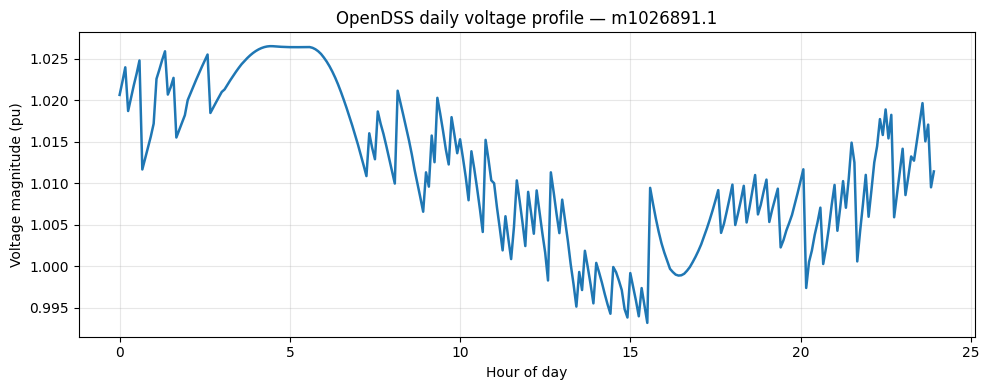

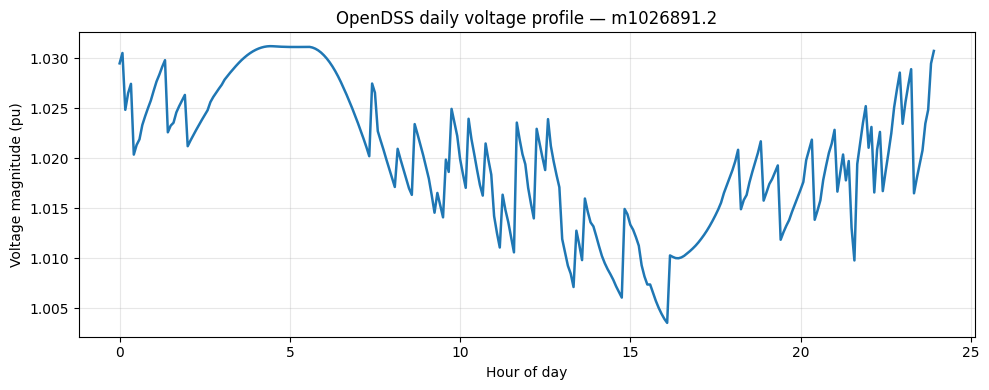

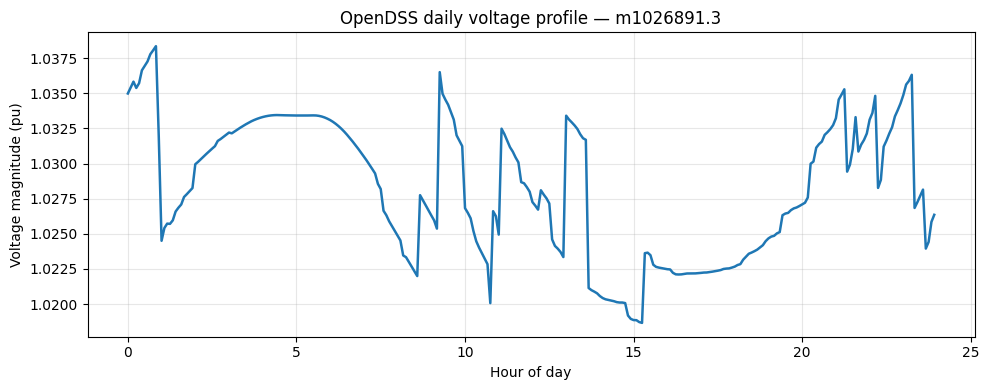

Daily solve done: nonconverged/failed steps=0, max-control-iter warnings=0


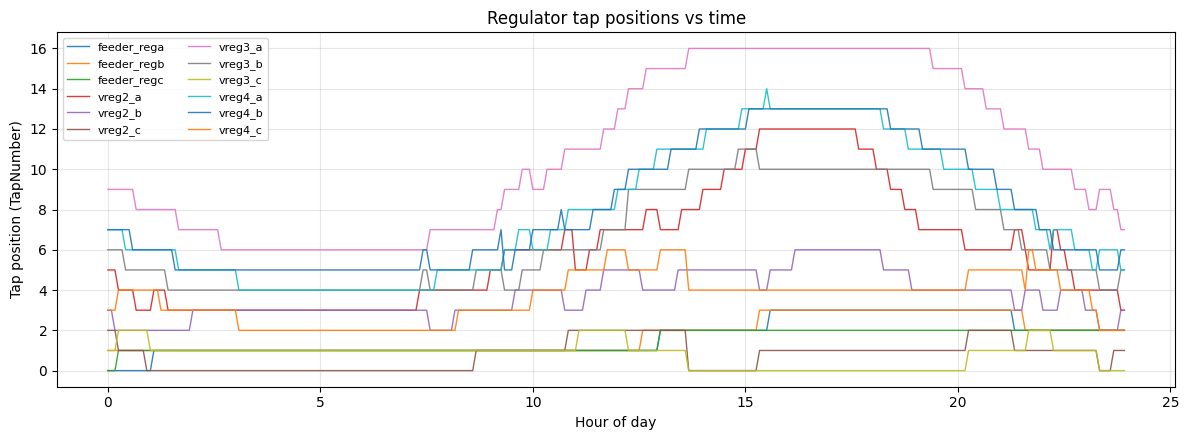

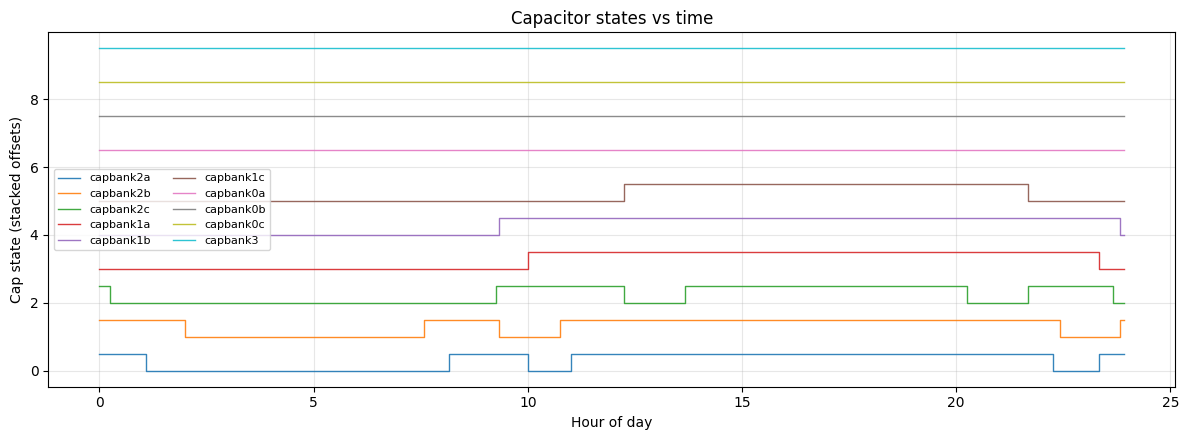


=== OpenDSS daily voltage distribution (all nodes, all timesteps) ===
count: 2456928
min: 0.910080
p01: 0.960014
p05: 0.980945
median: 1.017059
p95: 1.041299
p99: 1.048087
max: 1.062542
mean: 1.014826
std: 0.018810
frac_below_0p95: 0.618%
frac_in_0p95_1p05: 98.904%
frac_above_1p05: 0.478%


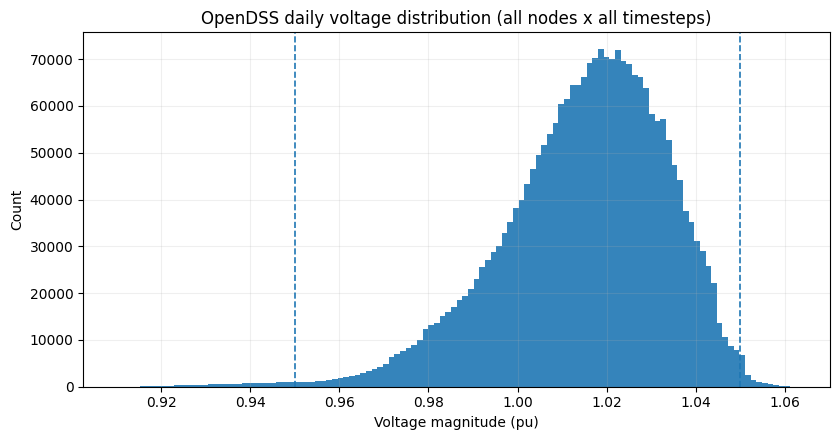


Saved:
 - c:\Users\alita\OneDrive\Desktop\GNN2\gnn2_daily_compare_8500_output
 - c:\Users\alita\OneDrive\Desktop\GNN2\gnn2_daily_compare_8500_output\opendss_daily_allnode_distribution_timeseries.csv


In [5]:
# Step 9 — OpenDSS-only daily solve (5-minute, 24h) + node plots + all-node voltage distribution
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import opendssdirect as dss
import run_injection_dataset as inj

# --- repo detection (local + Colab) ---
REPO_CANDIDATES = [
    os.getcwd(),
    r"C:\Users\alita\OneDrive\Desktop\GNN2",
    "/content/GNN-Sandia",
]
repo = None
for p in REPO_CANDIDATES:
    if os.path.isfile(os.path.join(p, "8500-node", "Run_8500Node_Daily_5min.dss")):
        repo = p
        break
if repo is None:
    raise FileNotFoundError(f"Could not locate repo root. Tried: {REPO_CANDIDATES}")
os.chdir(repo)
print("Using repo:", os.getcwd())

# --- config ---
NPTS = 288
STEP_MIN = 5
PLOT_NODES = ["m1026891.1", "m1026891.2", "m1026891.3"]  # edit as needed
OUT_DIR = "gnn2_daily_compare_8500_output"
os.makedirs(OUT_DIR, exist_ok=True)

RUN_DSS = os.path.join("8500-node", "Run_8500Node_Daily_5min.dss")
if not os.path.isfile(RUN_DSS):
    raise FileNotFoundError(os.path.abspath(RUN_DSS))

# --- compile/setup DSS daily entrypoint ---
# Use absolute path for robust execution.
dss.Basic.ClearAll()
dss.Text.Command(f'redirect "{os.path.abspath(RUN_DSS)}"')
# Keep daily settings explicit.
dss.Text.Command("set mode=daily")
dss.Text.Command("set stepsize=5m")
dss.Text.Command("set number=1")
# Important for 8500 daily control actions (regulators/cap controls).
dss.Text.Command("set maxiterations=30")
dss.Text.Command("set maxcontroliter=20000")

# Build node list from current compiled circuit (live DSS), not dataset CSV.
all_nodes = []
for n in dss.Circuit.AllNodeNames():
    s = str(n).strip().lower()
    if "." not in s:
        continue
    bus, phs = s.rsplit(".", 1)
    try:
        ph = int(phs)
    except Exception:
        continue
    if ph in (1, 2, 3):
        all_nodes.append(s)

# Preserve DSS order while deduplicating.
all_nodes = list(dict.fromkeys(all_nodes))
if len(all_nodes) == 0:
    raise RuntimeError("No phase nodes (1/2/3) found from dss.Circuit.AllNodeNames().")

node_to_idx = {n: i for i, n in enumerate(all_nodes)}

valid_plot_nodes = [str(n).lower() for n in PLOT_NODES if str(n).lower() in node_to_idx]
if len(valid_plot_nodes) == 0:
    valid_plot_nodes = [n for n in all_nodes if not n.startswith("sourcebus")][:3]
    print("[WARN] Requested nodes not found in live DSS nodes. Falling back to:", valid_plot_nodes)
elif len(valid_plot_nodes) < len(PLOT_NODES):
    missing = [n for n in PLOT_NODES if str(n).lower() not in node_to_idx]
    print("[WARN] Dropping missing nodes:", missing)

# --- run 24h day and collect voltages + control states ---
time_hours = np.arange(NPTS, dtype=np.float32) * (STEP_MIN / 60.0)
V_all = np.full((NPTS, len(all_nodes)), np.nan, dtype=np.float32)

# Track regulator taps and capacitor states over time.
reg_names = [n for n in dss.RegControls.AllNames() if str(n).lower() != "none"]
cap_names = [n for n in dss.Capacitors.AllNames() if str(n).lower() != "none"]

reg_taps = np.full((NPTS, len(reg_names)), np.nan, dtype=np.float32)
cap_states = np.full((NPTS, len(cap_names)), np.nan, dtype=np.float32)

n_nonconv = 0
n_ctrl_warn = 0
for t in range(NPTS):
    hr = int(t // 12)
    sec = int((t % 12) * 300)
    dss.Text.Command(f"set hour={hr} sec={sec}")
    try:
        dss.Solution.Solve()
    except Exception as e:
        # OpenDSS warning 485 can be raised as Python exception by opendssdirect.
        if "Max Control Iterations Exceeded" in str(e):
            n_ctrl_warn += 1
        n_nonconv += 1
        continue
    if not dss.Solution.Converged():
        n_nonconv += 1
        continue

    vmag, _ = inj.get_all_node_voltage_pu_and_angle_filtered(all_nodes)
    V_all[t, :] = np.asarray(vmag, dtype=np.float32)

    # Regulator tap positions
    for j, rn in enumerate(reg_names):
        try:
            dss.RegControls.Name(rn)
            reg_taps[t, j] = float(dss.RegControls.TapNumber())
        except Exception:
            reg_taps[t, j] = np.nan

    # Capacitor states: if multi-step state array exists, use 1 if any step is ON else 0
    for j, cn in enumerate(cap_names):
        try:
            dss.Capacitors.Name(cn)
            st = dss.Capacitors.States()
            if isinstance(st, (list, tuple, np.ndarray)):
                cap_states[t, j] = 1.0 if np.any(np.asarray(st, dtype=float) > 0.5) else 0.0
            else:
                cap_states[t, j] = float(st)
        except Exception:
            cap_states[t, j] = np.nan

    if (t + 1) % 24 == 0:
        print(f"[{t+1}/{NPTS}] daily solve collected", flush=True)

# --- plot selected node profiles ---
for n in valid_plot_nodes:
    i = node_to_idx[n]
    plt.figure(figsize=(10, 4))
    plt.plot(time_hours, V_all[:, i], linewidth=1.8)
    plt.xlabel("Hour of day")
    plt.ylabel("Voltage magnitude (pu)")
    plt.title(f"OpenDSS daily voltage profile — {n}")
    plt.grid(True, alpha=0.3)
    out_png = os.path.join(OUT_DIR, f"opendss_daily_profile_{n.replace('.', '_')}.png")
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.show()

print(f"Daily solve done: nonconverged/failed steps={n_nonconv}, max-control-iter warnings={n_ctrl_warn}")

# --- control traces plots (regulators + capacitors) ---
if len(reg_names) > 0:
    plt.figure(figsize=(12, 4.5))
    for j, rn in enumerate(reg_names):
        plt.plot(time_hours, reg_taps[:, j], linewidth=1.0, alpha=0.9, label=rn)
    plt.xlabel("Hour of day")
    plt.ylabel("Tap position (TapNumber)")
    plt.title("Regulator tap positions vs time")
    plt.grid(True, alpha=0.3)
    # Too many legend entries can clutter the plot.
    if len(reg_names) <= 12:
        plt.legend(ncol=2, fontsize=8)
    reg_png = os.path.join(OUT_DIR, "opendss_daily_regulator_taps.png")
    plt.tight_layout()
    plt.savefig(reg_png, dpi=170)
    plt.show()

if len(cap_names) > 0:
    plt.figure(figsize=(12, 4.5))
    for j, cn in enumerate(cap_names):
        # vertical offset so state traces are distinguishable
        y = cap_states[:, j] * 0.5 + 1.0 * j
        plt.step(time_hours, y, where="post", linewidth=1.0, alpha=0.9, label=cn)
    plt.xlabel("Hour of day")
    plt.ylabel("Cap state (stacked offsets)")
    plt.title("Capacitor states vs time")
    plt.grid(True, alpha=0.3)
    if len(cap_names) <= 12:
        plt.legend(ncol=2, fontsize=8)
    cap_png = os.path.join(OUT_DIR, "opendss_daily_capacitor_states.png")
    plt.tight_layout()
    plt.savefig(cap_png, dpi=170)
    plt.show()

# --- all-node all-day distribution ---
vals = V_all[np.isfinite(V_all)]
if vals.size == 0:
    raise RuntimeError("No converged finite voltages collected for daily run.")

summary = {
    "count": int(vals.size),
    "min": float(np.min(vals)),
    "p01": float(np.percentile(vals, 1)),
    "p05": float(np.percentile(vals, 5)),
    "median": float(np.percentile(vals, 50)),
    "p95": float(np.percentile(vals, 95)),
    "p99": float(np.percentile(vals, 99)),
    "max": float(np.max(vals)),
    "mean": float(np.mean(vals)),
    "std": float(np.std(vals)),
    "frac_below_0p95": float(np.mean(vals < 0.95)),
    "frac_in_0p95_1p05": float(np.mean((vals >= 0.95) & (vals <= 1.05))),
    "frac_above_1p05": float(np.mean(vals > 1.05)),
}

print("\n=== OpenDSS daily voltage distribution (all nodes, all timesteps) ===")
for k, v in summary.items():
    if k.startswith("frac_"):
        print(f"{k}: {100.0*v:.3f}%")
    else:
        print(f"{k}: {v:.6f}" if isinstance(v, float) else f"{k}: {v}")

# Histogram for all node-phase voltages across full day.
plt.figure(figsize=(8.5, 4.5))
plt.hist(vals, bins=120, alpha=0.9)
plt.axvline(0.95, linestyle="--", linewidth=1.2)
plt.axvline(1.05, linestyle="--", linewidth=1.2)
plt.xlabel("Voltage magnitude (pu)")
plt.ylabel("Count")
plt.title("OpenDSS daily voltage distribution (all nodes x all timesteps)")
plt.grid(True, alpha=0.2)
hist_png = os.path.join(OUT_DIR, "opendss_daily_allnode_voltage_hist.png")
plt.tight_layout()
plt.savefig(hist_png, dpi=170)
plt.show()

# Persist per-step distribution stats as CSV.
df_step = pd.DataFrame({
    "t_index": np.arange(NPTS, dtype=int),
    "hour": time_hours,
    "n_finite": np.sum(np.isfinite(V_all), axis=1),
    "vmin": np.nanmin(V_all, axis=1),
    "vmax": np.nanmax(V_all, axis=1),
    "vmean": np.nanmean(V_all, axis=1),
    "v_p05": np.nanpercentile(V_all, 5, axis=1),
    "v_p50": np.nanpercentile(V_all, 50, axis=1),
    "v_p95": np.nanpercentile(V_all, 95, axis=1),
})
out_csv = os.path.join(OUT_DIR, "opendss_daily_allnode_distribution_timeseries.csv")
df_step.to_csv(out_csv, index=False)
print("\nSaved:")
print(" -", os.path.abspath(OUT_DIR))
print(" -", os.path.abspath(out_csv))

In [6]:
import os, hashlib

CANDIDATES = [
    r"C:\Users\alita\OneDrive\Desktop\GNN2",
    "/content/GNN-Sandia",
    os.getcwd(),
]

script_path = None
for root in CANDIDATES:
    p = os.path.join(root, "run_daily_aggregate_dataset_8500.py")
    if os.path.isfile(p):
        script_path = os.path.abspath(p)
        break

if script_path is None:
    raise FileNotFoundError("run_daily_aggregate_dataset_8500.py not found in candidates.")

os.chdir(os.path.dirname(script_path))
print("CWD:", os.getcwd())
print("SCRIPT:", script_path)

# Verify this is the updated script
txt = open(script_path, encoding="utf-8").read()
print("has_new_diag:", ("top_offenders" in txt and "pct_out" in txt and "n_v_below_safe_band" in txt))
print("md5:", hashlib.md5(txt.encode("utf-8")).hexdigest())

exec(txt, {"__name__": "__main__", "__file__": script_path})

CWD: c:\Users\alita\OneDrive\Desktop\GNN2
SCRIPT: C:\Users\alita\OneDrive\Desktop\GNN2\run_daily_aggregate_dataset_8500.py
has_new_diag: True
md5: 28915d51c66e26727663cd9a37b4ab9e
[diag] safe-band eval: 8531/8531 nodes (all phase nodes, no kVBase filter — aligned with notebook Step 9)
[saved] phase-edge CSV -> C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\gnn_edges_phase_static.csv | rows=14238 | cols=17 | bidirectional=True
[diag] regcontrols=12 capacitors=10
[scenario 1/500] scale=0.788 kept_samples=20 nonconv_this_s=0 badV_this_s=0 v_outside_band_this_s=0 (below=0, above=0, pct=0.00%) N_nodes=8531 top_offenders=[none] skip_nonconv_total=0 skip_badV_total=0
[scenario 2/500] scale=1.241 kept_samples=38 nonconv_this_s=2 badV_this_s=0 v_outside_band_this_s=24 (below=24, above=0, pct=0.02%) N_nodes=8531 top_offenders=[sx3235946a.1:1, sx3235946a.2:1, sx3011229a.1:1, sx3011229a.2:1, sx2767342a.1:1] skip_nonconv_total=2 skip_badV_total=0
[scenario 3/500] scale=0.

In [1]:
import os
import pandas as pd

base = r"C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg"

sample_csv = os.path.join(base, "gnn_sample_meta.csv")
node_csv   = os.path.join(base, "gnn_node_features_and_targets.csv")
edge_csv   = os.path.join(base, "gnn_edges_phase_static.csv")

print("=== sample meta (first 5 rows) ===")
df_s = pd.read_csv(sample_csv, nrows=5)
print(df_s)

print("\n=== node features/targets (first 5 rows) ===")
df_n = pd.read_csv(node_csv, nrows=5)
print(df_n)

print("\n=== edges (first 5 rows) ===")
df_e = pd.read_csv(edge_csv, nrows=5)
print(df_e)

=== sample meta (first 5 rows) ===
   sample_id  scenario_id  t_index  t_minutes  scenario_total_load_scale  \
0          0            0       53        265                   0.788291   
1          1            0      197        985                   0.788291   
2          2            0       71        355                   0.788291   
3          3            0       50        250                   0.788291   
4          4            0       55        275                   0.788291   

   m_loadshape  effective_total_scale  P_load_total_kw  Q_load_total_kvar  \
0     0.568089               0.447819      4825.839491        1210.121651   
1     1.052582               0.829741      8934.354718        2237.873385   
2     0.570981               0.450099      4849.734586        1215.053958   
3     0.568722               0.448318      4822.367653        1211.218997   
4     0.568204               0.447910      4822.929913        1209.624227   

   P_load_total_kw_nominal  Q_load_total_kvar

### 8500 device-state MLP architecture search

Trains five **non-graph** MLPs on the flattened nodal vector (**p_load_kw**, **q_load_kvar** for every node) to predict **22** device-state targets in `gnn_sample_meta.csv`. No edge or static graph features are used. Checkpoints (`best.pt`) and `summary.json` are written to `gnn2_architecture_search/`. The first run streams the large node CSV once; `--node-cache` saves a tensor `.pt` for faster reruns.

**Colab:** Run your **setup cell** first (clone to `/content/GNN-Sandia` and `chdir` there), or ensure the cwd is the repo root so `train_8500_device_state_arch_search.py` is visible. The training cell also checks `/content/GNN-Sandia` and `/content/GNN2`. Optional: `os.environ["GNN_REPO"] = "/content/GNN-Sandia"`.

Then add `datasets_gnn2/loadtype_8500_dailyagg/` (upload or Google Drive).

In [ ]:
import os
import subprocess
import sys
from pathlib import Path


def _detect_repo_root() -> Path:
    """Return a directory that contains train_8500_device_state_arch_search.py (never a non-existent path)."""
    marker = "train_8500_device_state_arch_search.py"

    def _has_script(p: Path) -> bool:
        return (p / marker).is_file()

    env = (os.environ.get("GNN2_REPO") or os.environ.get("GNN_REPO") or "").strip()
    if env:
        p = Path(env).expanduser().resolve()
        if _has_script(p):
            return p
        raise FileNotFoundError(
            f"GNN2_REPO/GNN_REPO={env!r} but {marker} not found there. Fix the path or unset the env var."
        )

    # If the notebook cwd is already the repo (e.g. after os.chdir("/content/GNN-Sandia")), use it.
    cwd = Path.cwd().resolve()
    if _has_script(cwd):
        return cwd

    try:
        import google.colab  # noqa: F401

        _colab = True
    except ImportError:
        _colab = False

    if _colab:
        # Match common Colab clone targets (setup cell often uses /content/GNN-Sandia)
        for p in (
            Path("/content/GNN-Sandia"),
            Path("/content/GNN2"),
            Path("/content/drive/MyDrive/GNN-Sandia"),
            Path("/content/drive/MyDrive/GNN2"),
            Path("/content/drive/MyDrive/Desktop/GNN2"),
        ):
            if _has_script(p):
                return p.resolve()

    win = Path(r"C:\Users\alita\OneDrive\Desktop\GNN2")
    if _has_script(win):
        return win.resolve()

    raise FileNotFoundError(
        "Cannot find the repo (missing train_8500_device_state_arch_search.py).\n"
        "On Colab run your setup cell first (clone + chdir), e.g.:\n"
        "  !git clone https://github.com/alitasavori/GNN-Sandia.git /content/GNN-Sandia\n"
        "  %cd /content/GNN-Sandia\n"
        "Or set: os.environ['GNN_REPO'] = '/content/GNN-Sandia'"
    )


repo = str(_detect_repo_root())
os.chdir(repo)
outd = os.path.join(repo, "gnn2_architecture_search")
cache = os.path.join(outd, "node_features_X.pt")
os.makedirs(outd, exist_ok=True)

cmd = [
    sys.executable,
    "train_8500_device_state_arch_search.py",
    "--repo-root",
    repo,
    "--epochs",
    "100",
    "--out-dir",
    outd,
    "--node-cache",
    cache,
]
print("Running:", " ".join(cmd))
subprocess.run(cmd, check=True)